In [ ]:
import os
import random
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

In [ ]:
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

set_seed(42)

def l2_norm(x):
    return x / (x.norm(p=2, dim=1, keepdim=True) + 1e-10)


In [ ]:
class CowEmbeddingDataset(Dataset):
    def __init__(self, root, transform):
        self.samples = []
        self.cow_ids = []
        self.transform = transform

        for cow in sorted(os.listdir(root)):
            cdir = os.path.join(root, cow)
            if not os.path.isdir(cdir): continue
            imgs = [os.path.join(cdir,f) for f in os.listdir(cdir) if f.lower().endswith(('jpg','png','jpeg'))]
            if len(imgs)==0: continue
            self.cow_ids.append(cow)
            for p in imgs: self.samples.append((p, cow))

        self.id2idx = {cid:i for i,cid in enumerate(self.cow_ids)}

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, cow = self.samples[idx]
        img = Image.open(path).convert('RGB')
        img = self.transform(img)
        return img, self.id2idx[cow], cow, path

In [ ]:
class PairedCowDataset(Dataset):
    def __init__(self, face_root, muzzle_root, tf_f, tf_m):
        self.tf_f = tf_f; self.tf_m = tf_m

        face_cows = set(os.listdir(face_root))
        muzzle_cows = set(os.listdir(muzzle_root))
        self.cows = sorted(list(face_cows.union(muzzle_cows)))

        self.face_paths = {}
        self.muzzle_paths = {}
        for cid in self.cows:
            fdir = os.path.join(face_root, cid)
            mdir = os.path.join(muzzle_root, cid)
            self.face_paths[cid] = [os.path.join(fdir,f) for f in os.listdir(fdir)] if os.path.isdir(fdir) else []
            self.muzzle_paths[cid] = [os.path.join(mdir,f) for f in os.listdir(mdir)] if os.path.isdir(mdir) else []

    def __len__(self): return len(self.cows)

    def __getitem__(self, idx):
        cid = self.cows[idx]
        f = m = None
        fp = random.choice(self.face_paths[cid]) if self.face_paths[cid] else None
        mp = random.choice(self.muzzle_paths[cid]) if self.muzzle_paths[cid] else None

        if fp:
            f = Image.open(fp).convert('RGB')
            f = self.tf_f(f)
        if mp:
            m = Image.open(mp).convert('RGB')
            m = self.tf_m(m)
        return f, m, cid

In [ ]:
class TransformerHead(nn.Module):
    def __init__(self, dim, layers=6):
        super().__init__()
        block = nn.TransformerEncoderLayer(dim, nhead=8, batch_first=True)
        self.encoder = nn.TransformerEncoder(block, num_layers=layers)

    def forward(self, x):  # x: (B, L, C)
        return self.encoder(x)

In [ ]:
class EmbeddingNet(nn.Module):
    def __init__(self, backbone='resnet50', proj_dim=512, t_layers=6):
        super().__init__()
        base = models.resnet50 if backbone=='resnet50' else models.resnet101
        cnn = base(weights=models.ResNet50_Weights.DEFAULT if backbone=='resnet50' else models.ResNet101_Weights.DEFAULT)
        self.cnn = nn.Sequential(*list(cnn.children())[:-2])

        self.proj = nn.Conv2d(2048, 2048, 1)
        self.token_linear = nn.Linear(2048, 2048)
        self.transformer = TransformerHead(2048, layers=t_layers)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(2048, proj_dim)

    def forward(self, x):
        f = self.cnn(x)             # (B,2048,H,W)
        f = self.proj(f)
        B,C,H,W = f.shape
        t = f.view(B,C,-1).permute(0,2,1) # (B,L,C)
        t = self.token_linear(t)
        t = self.transformer(t)
        t = t.permute(0,2,1)
        pooled = self.pool(t).squeeze(-1)
        emb = self.fc(pooled)
        return F.normalize(emb, p=2, dim=1)

In [ ]:
class ArcFaceLoss(nn.Module):
    def __init__(self, dim, num_classes, s=30, m=0.5):
        super().__init__()
        self.W = nn.Parameter(torch.randn(dim, num_classes))
        nn.init.xavier_uniform_(self.W)
        self.s = s; self.m = m

    def forward(self, emb, labels):
        W = F.normalize(self.W, p=2, dim=0)
        logits = emb @ W
        logits = logits.clamp(-1+1e-7,1-1e-7)
        theta = torch.acos(logits)
        target = torch.cos(theta + self.m)
        one_hot = F.one_hot(labels, logits.size(1)).float().to(emb.device)
        output = logits*(1-one_hot) + target*one_hot
        return F.cross_entropy(self.s*output, labels)

In [ ]:
def train_model(model, loader, num_classes, device, epochs=10, lr=1e-4):
    model = model.to(device)
    crit = ArcFaceLoss(model.fc.out_features, num_classes).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)

    for ep in range(epochs):
        model.train(); total=0; loss_sum=0
        for imgs, labels, _, _ in loader:
            imgs = imgs.to(device); labels = labels.to(device)
            opt.zero_grad()
            emb = model(imgs)
            loss = crit(emb, labels)
            loss.backward(); opt.step()
            loss_sum += loss.item()*imgs.size(0)
            total += imgs.size(0)
        print(f"Epoch {ep+1}/{epochs} | Loss={loss_sum/total:.4f}")
    return model

In [ ]:
def build_gallery(model, root, transform, device):
    model.eval(); gallery={}
    for cid in sorted(os.listdir(root)):
        cdir=os.path.join(root,cid)
        if not os.path.isdir(cdir): continue
        embs=[]
        for f in os.listdir(cdir):
            if not f.lower().endswith(('jpg','png','jpeg')): continue
            img=transform(Image.open(os.path.join(cdir,f)).convert('RGB')).unsqueeze(0).to(device)
            with torch.no_grad(): e=model(img).cpu().numpy()[0]
            e=e/(np.linalg.norm(e)+1e-10)
            embs.append(e)
        if len(embs)>0: gallery[cid]=np.mean(embs,axis=0)
    return gallery

In [ ]:
def compute_unknown_scores(model, val_root, gallery, transform, device):
    scores=[]
    for cid in os.listdir(val_root):
        cdir=os.path.join(val_root,cid)
        if not os.path.isdir(cdir): continue
        for f in os.listdir(cdir):
            if not f.endswith(('jpg','png','jpeg')): continue
            img=transform(Image.open(os.path.join(cdir,f)).convert('RGB')).unsqueeze(0).to(device)
            with torch.no_grad(): e=model(img).cpu().numpy()[0]
            for gcid,gemb in gallery.items():
                scores.append(np.dot(e,gemb)/(np.linalg.norm(e)*np.linalg.norm(gemb)+1e-10))
    return max(scores) if scores else 0.6

In [ ]:
def estimate_thresholds(face_m, muzzle_m, face_val, muzzle_val, gal_f, gal_m, tf, device):
    th_f = compute_unknown_scores(face_m, face_val, gal_f, tf, device) + 0.02
    th_m = compute_unknown_scores(muzzle_m, muzzle_val, gal_m, tf, device) + 0.02
    th_fus = max(th_f, th_m)  # safe fallback
    return th_f, th_m, th_fus

In [ ]:
def cosine(a,b): return float(np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b)+1e-10))


def verify_pair(face_emb, muzzle_emb, gal_f, gal_m, th_f, th_m, th_fus,
                wf=0.6, wm=0.4, margin=0.05):
    scores=[]
    cows=set(list(gal_f.keys())+list(gal_m.keys()))
    for cid in cows:
        sf = cosine(face_emb, gal_f[cid]) if face_emb is not None and cid in gal_f else -1
        sm = cosine(muzzle_emb, gal_m[cid]) if muzzle_emb is not None and cid in gal_m else -1
        fused = wf*max(sf,0)+wm*max(sm,0)
        scores.append((cid,sf,sm,fused))

    scores.sort(key=lambda x:x[3], reverse=True)
    best, second = scores[0], scores[1]
    cid, sf, sm, fus = best

    if fus-second[3] < margin: return None, fus, 'low_margin'
    if sf>=th_f and sm>=th_m and fus>=th_fus: return cid, fus, 'accept'
    return None, fus, 'reject'

In [ ]:
def eval_test(face_m, muzzle_m, face_test, muzzle_test, gal_f, gal_m, tf, device,
             th_f, th_m, th_fus):
    results=[]
    for cid in sorted(os.listdir(face_test)):
        fdir=os.path.join(face_test,cid)
        mdir=os.path.join(muzzle_test,cid)
        fimgs=[os.path.join(fdir,f) for f in os.listdir(fdir)] if os.path.isdir(fdir) else []
        mimgs=[os.path.join(mdir,f) for f in os.listdir(mdir)] if os.path.isdir(mdir) else []

        for fp in fimgs:
            face_emb=None; muzzle_emb=None
            try:
                img=tf(Image.open(fp).convert('RGB')).unsqueeze(0).to(device)
                with torch.no_grad(): face_emb=face_m(img).cpu().numpy()[0]
            except: pass

            if mimgs:
                mp=random.choice(mimgs)
                try:
                    img=tf(Image.open(mp).convert('RGB')).unsqueeze(0).to(device)
                    with torch.no_grad(): muzzle_emb=muzzle_m(img).cpu().numpy()[0]
                except: pass

            pred,score,reason = verify_pair(face_emb,muzzle_emb,
                                            gal_f,gal_m,
                                            th_f,th_m,th_fus)
            results.append({'true':cid,'img':fp,'pred':pred,'score':score,'reason':reason})
    return results

In [ ]:
import os
import torch
import numpy as np
from PIL import Image


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE =", device)

DEVICE = cuda


In [ ]:
DATA_ROOT = "/content/drive/MyDrive/cattle_data_crops"   # <-- change to your path

FACE_TRAIN   = os.path.join(DATA_ROOT, "face_try")
MUZZLE_TRAIN = os.path.join(DATA_ROOT, "muzzle_try")

FACE_VAL     = os.path.join(DATA_ROOT, "face_try_validate")
MUZZLE_VAL   = os.path.join(DATA_ROOT, "muzzle_try_validate")

FACE_TEST    = os.path.join(DATA_ROOT, "face_try_test")
MUZZLE_TEST  = os.path.join(DATA_ROOT, "Muzzle_try_test")

print("Training cows:", len(os.listdir(FACE_TRAIN)))

Training cows: 345


In [ ]:
import torchvision.transforms as T

train_tf = T.Compose([
    T.Resize((256,256)),
    T.RandomResizedCrop(224, scale=(0.8,1.0)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.1,0.1,0.1,0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

test_tf = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])


In [ ]:

face_train_ds   = CowEmbeddingDataset(FACE_TRAIN, transform=train_tf)
muzzle_train_ds = CowEmbeddingDataset(MUZZLE_TRAIN, transform=train_tf)

face_loader   = DataLoader(face_train_ds, batch_size=32, shuffle=True)
muzzle_loader = DataLoader(muzzle_train_ds, batch_size=32, shuffle=True)

print("Face train samples:", len(face_train_ds))
print("Muzzle train samples:", len(muzzle_train_ds))

Face train samples: 3510
Muzzle train samples: 3534


In [ ]:
face_model = EmbeddingNet(backbone="resnet50",  proj_dim=512, t_layers=6)
muzzle_model = EmbeddingNet(backbone="resnet101", proj_dim=512, t_layers=6)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 211MB/s]


Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


100%|██████████| 171M/171M [00:01<00:00, 174MB/s]


In [ ]:
print("Training FACE model...")
face_model = train_model(
    face_model,
    loader=face_loader,
    num_classes=len(face_train_ds.cow_ids),
    device=device,
    epochs=10,
    lr=2e-5
)

Training FACE model...
Epoch 1/10 | Loss=19.3356
Epoch 2/10 | Loss=14.2363
Epoch 3/10 | Loss=9.9443
Epoch 4/10 | Loss=6.2591
Epoch 5/10 | Loss=3.3580
Epoch 6/10 | Loss=1.5731
Epoch 7/10 | Loss=0.7985
Epoch 8/10 | Loss=0.4311
Epoch 9/10 | Loss=0.2400
Epoch 10/10 | Loss=0.1510


In [ ]:
print("Training MUZZLE model...")
muzzle_model = train_model(
    muzzle_model,
    loader=muzzle_loader,
    num_classes=len(muzzle_train_ds.cow_ids),
    device=device,
    epochs=6,
    lr=2e-5
)

Training MUZZLE model...
Epoch 1/6 | Loss=19.4999
Epoch 2/6 | Loss=15.6953
Epoch 3/6 | Loss=12.0208
Epoch 4/6 | Loss=8.7481
Epoch 5/6 | Loss=5.7159
Epoch 6/6 | Loss=3.5255


In [ ]:
face_gallery   = build_gallery(face_model, FACE_TRAIN, test_tf, device)
muzzle_gallery = build_gallery(muzzle_model, MUZZLE_TRAIN, test_tf, device)

print("Face gallery size:", len(face_gallery))
print("Muzzle gallery size:", len(muzzle_gallery))


Face gallery size: 345
Muzzle gallery size: 345


In [ ]:
th_face, th_muzzle, th_fusion = estimate_thresholds(
    face_model, muzzle_model,
    FACE_VAL, MUZZLE_VAL,
    face_gallery, muzzle_gallery,
    test_tf, device
)

In [ ]:
print("THRESHOLDS →")
print("Face threshold:", th_face)
print("Muzzle threshold:", th_muzzle)
print("Fusion threshold:", th_fusion)

THRESHOLDS →
Face threshold: 0.8359088
Muzzle threshold: 0.92084175
Fusion threshold: 0.92084175


In [ ]:
results = eval_test(
    face_model, muzzle_model,
    FACE_TEST, MUZZLE_TEST,
    face_gallery, muzzle_gallery,
    test_tf, device,
    th_face, th_muzzle, th_fusion
)

print("Total test samples:", len(results))

Total test samples: 925


In [ ]:
FP = 0; TP = 0; FN = 0
known_cows = set(list(face_gallery.keys()) + list(muzzle_gallery.keys()))

for r in results:
    true = r['true']
    pred = r['pred']

    if pred is None:
        if true in known_cows:
            FN += 1     # should match but rejected
    else:
        if pred == true:
            TP += 1     # correct identification
        else:
            FP += 1     # wrong cow → FALSE ACCEPTANCE

print("\n=== METRICS ===")
print("TP =", TP)
print("FP =", FP)
print("FN =", FN)

TAR = TP / max(1, TP + FN)
FAR = FP / max(1, len(results))

print("TAR (True Accept Rate) =", TAR)
print("FAR (False Accept Rate) =", FAR)

# Save results if needed
import pandas as pd
df = pd.DataFrame(results)
df.to_csv("/content/drive/MyDrive/cow_test_results.csv", index=False)
print("Saved: cow_test_results.csv")


=== METRICS ===
TP = 0
FP = 0
FN = 0
TAR (True Accept Rate) = 0.0
FAR (False Accept Rate) = 0.0
Saved: cow_test_results.csv


In [ ]:
import random
import numpy as np
import pandas as pd

def evaluate_with_thresholds(th_face, th_muzzle, th_fusion,
                             face_model, muzzle_model,
                             FACE_TEST, MUZZLE_TEST,
                             face_gallery, muzzle_gallery,
                             test_tf, device):

    results = eval_test(
        face_model, muzzle_model,
        FACE_TEST, MUZZLE_TEST,
        face_gallery, muzzle_gallery,
        test_tf, device,
        th_face, th_muzzle, th_fusion
    )

    TP = FP = FN = 0
    known_cows = set(list(face_gallery.keys()) + list(muzzle_gallery.keys()))

    for r in results:
        true = r["true"]
        pred = r["pred"]

        if pred is None:
            if true in known_cows:
                FN += 1
        else:
            if pred == true:
                TP += 1
            else:
                FP += 1

    total_known = TP + FN if TP+FN > 0 else 1
    TAR = TP / total_known
    FAR = FP / max(1, len(results))

    return TP, FP, FN, TAR, FAR, results


# ====================================================
# RANDOM THRESHOLD SEARCH LOOP
# ====================================================

N = 20   # number of random trials

trial_results = []

for i in range(N):
    th_face   = round(random.uniform(0.30, 0.70), 3)
    th_muzzle = round(random.uniform(0.30, 0.80), 3)
    th_fusion = round(random.uniform(0.30, 0.85), 3)

    TP, FP, FN, TAR, FAR, _ = evaluate_with_thresholds(
        th_face, th_muzzle, th_fusion,
        face_model, muzzle_model,
        FACE_TEST, MUZZLE_TEST,
        face_gallery, muzzle_gallery,
        test_tf, device
    )

    trial_results.append({
        "th_face": th_face,
        "th_muzzle": th_muzzle,
        "th_fusion": th_fusion,
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "TAR": TAR,
        "FAR": FAR
    })

    print(f"[{i+1}/{N}] th_face={th_face} | th_muzzle={th_muzzle} | th_fusion={th_fusion}")
    print(f"   → TP={TP}, FP={FP}, FN={FN}, TAR={TAR:.3f}, FAR={FAR:.3f}")

# Convert to DataFrame for easier analysis
df_thresh = pd.DataFrame(trial_results)
df_thresh


[1/20] th_face=0.643 | th_muzzle=0.465 | th_fusion=0.682
   → TP=0, FP=10, FN=0, TAR=0.000, FAR=0.011
[2/20] th_face=0.591 | th_muzzle=0.756 | th_fusion=0.638
   → TP=0, FP=4, FN=0, TAR=0.000, FAR=0.004
[3/20] th_face=0.645 | th_muzzle=0.306 | th_fusion=0.528
   → TP=0, FP=11, FN=0, TAR=0.000, FAR=0.012
[4/20] th_face=0.479 | th_muzzle=0.433 | th_fusion=0.437
   → TP=0, FP=16, FN=0, TAR=0.000, FAR=0.017
[5/20] th_face=0.631 | th_muzzle=0.739 | th_fusion=0.708
   → TP=0, FP=6, FN=0, TAR=0.000, FAR=0.006
[6/20] th_face=0.581 | th_muzzle=0.696 | th_fusion=0.369
   → TP=0, FP=7, FN=0, TAR=0.000, FAR=0.008
[7/20] th_face=0.326 | th_muzzle=0.404 | th_fusion=0.682
   → TP=0, FP=10, FN=0, TAR=0.000, FAR=0.011
[8/20] th_face=0.383 | th_muzzle=0.537 | th_fusion=0.777
   → TP=0, FP=10, FN=0, TAR=0.000, FAR=0.011
[9/20] th_face=0.332 | th_muzzle=0.701 | th_fusion=0.465
   → TP=0, FP=8, FN=0, TAR=0.000, FAR=0.009
[10/20] th_face=0.416 | th_muzzle=0.397 | th_fusion=0.622
   → TP=0, FP=11, FN=0, TAR=

,th_face,th_muzzle,th_fusion,TP,FP,FN,TAR,FAR
0,0.643,0.465,0.682,0,10,0,0.0,0.010811
1,0.591,0.756,0.638,0,4,0,0.0,0.004324
2,0.645,0.306,0.528,0,11,0,0.0,0.011892
3,0.479,0.433,0.437,0,16,0,0.0,0.017297
4,0.631,0.739,0.708,0,6,0,0.0,0.006486
5,0.581,0.696,0.369,0,7,0,0.0,0.007568
6,0.326,0.404,0.682,0,10,0,0.0,0.010811
7,0.383,0.537,0.777,0,10,0,0.0,0.010811
8,0.332,0.701,0.465,0,8,0,0.0,0.008649
9,0.416,0.397,0.622,0,11,0,0.0,0.011892


In [ ]:
# Save the random threshold search results to a CSV file
output_csv_path = "/content/drive/MyDrive/random_threshold_search_results.csv"
df_thresh.to_csv(output_csv_path, index=False)
print(f"Random threshold search results saved to: {output_csv_path}")


Random threshold search results saved to: /content/drive/MyDrive/random_threshold_search_results.csv


In [ ]:
import os

def compare_train_test_ids(FACE_TRAIN, MUZZLE_TRAIN, FACE_TEST, MUZZLE_TEST):
    # Get cow IDs from folder names
    train_face_ids   = set([d for d in os.listdir(FACE_TRAIN) if os.path.isdir(os.path.join(FACE_TRAIN, d))])
    train_muzzle_ids = set([d for d in os.listdir(MUZZLE_TRAIN) if os.path.isdir(os.path.join(MUZZLE_TRAIN, d))])

    test_face_ids    = set([d for d in os.listdir(FACE_TEST) if os.path.isdir(os.path.join(FACE_TEST, d))])
    test_muzzle_ids  = set([d for d in os.listdir(MUZZLE_TEST) if os.path.isdir(os.path.join(MUZZLE_TEST, d))])

    # Combined train/test sets
    train_ids = train_face_ids.union(train_muzzle_ids)
    test_ids  = test_face_ids.union(test_muzzle_ids)

    # Check overlap
    common_ids = train_ids.intersection(test_ids)
    only_in_test = test_ids - train_ids
    only_in_train = train_ids - test_ids

    print("=== SUMMARY ===")
    print("Train cows:", len(train_ids))
    print("Test cows:", len(test_ids))
    print("Common cows (in BOTH train and test):", len(common_ids))
    print("Unique test cows:", len(only_in_test))
    print("Unique train cows:", len(only_in_train))

    print("\nCommon cow IDs (if any):")
    for cid in sorted(list(common_ids))[:20]:
        print("  ", cid)

    return common_ids, only_in_test

# RUN
common_ids, unseen_test_ids = compare_train_test_ids(
    FACE_TRAIN, MUZZLE_TRAIN,
    FACE_TEST, MUZZLE_TEST
)


=== SUMMARY ===
Train cows: 345
Test cows: 93
Common cows (in BOTH train and test): 0
Unique test cows: 93
Unique train cows: 345

Common cow IDs (if any):


In [ ]:
import random
import os
import numpy as np
from PIL import Image

def evaluate_random_train_samples(face_model, muzzle_model,
                                  FACE_TRAIN, MUZZLE_TRAIN,
                                  face_gallery, muzzle_gallery,
                                  test_tf, device,
                                  th_face, th_muzzle, th_fusion,
                                  num_samples=100):

    # Collect random samples
    face_paths = []
    for cid in os.listdir(FACE_TRAIN):
        cdir = os.path.join(FACE_TRAIN, cid)
        if not os.path.isdir(cdir): continue

        imgs = [os.path.join(cdir, f)
                for f in os.listdir(cdir)
                if f.lower().endswith(("jpg","png","jpeg"))]

        for p in imgs:
            face_paths.append((p, cid))

    # sample 100
    random.shuffle(face_paths)
    face_paths = face_paths[:num_samples]

    TP = FP = FN = 0
    results = []

    for fp, true_cow in face_paths:
        # Load face embedding
        face_emb = None
        try:
            img = test_tf(Image.open(fp).convert("RGB")).unsqueeze(0).to(device)
            with torch.no_grad():
                face_emb = face_model(img).cpu().numpy()[0]
        except:
            pass

        # Load a muzzle image from the same cow (if available)
        muzzle_emb = None
        muzzle_dir = os.path.join(MUZZLE_TRAIN, true_cow)
        if os.path.isdir(muzzle_dir):
            mimgs = [os.path.join(muzzle_dir, f)
                     for f in os.listdir(muzzle_dir)
                     if f.lower().endswith(("jpg","png","jpeg"))]
            if mimgs:
                mp = random.choice(mimgs)
                try:
                    img = test_tf(Image.open(mp).convert("RGB")).unsqueeze(0).to(device)
                    with torch.no_grad():
                        muzzle_emb = muzzle_model(img).cpu().numpy()[0]
                except:
                    pass

        pred, score, reason = verify_pair(face_emb, muzzle_emb,
                                          face_gallery, muzzle_gallery,
                                          th_face, th_muzzle, th_fusion)

        results.append((true_cow, pred, score, reason))

        if pred is None:
            FN += 1
        else:
            if pred == true_cow:
                TP += 1
            else:
                FP += 1

    return TP, FP, FN, results


# RUN THE TEST
TP, FP, FN, rand_results = evaluate_random_train_samples(
    face_model, muzzle_model,
    FACE_TRAIN, MUZZLE_TRAIN,
    face_gallery, muzzle_gallery,
    test_tf, device,
    th_face=0.4, th_muzzle=0.5, th_fusion=0.55,   # use safe thresholds
    num_samples=100
)

print("=== RANDOM TRAIN EVALUATION ===")
print("TP:", TP)
print("FP:", FP)
print("FN:", FN)
print("TAR:", TP / (TP + FN + 1e-6))
print("FAR:", FP / (TP + FP + FN + 1e-6))

# Print first 20 predictions
for r in rand_results[:20]:
    print(r)


=== RANDOM TRAIN EVALUATION ===
TP: 99
FP: 0
FN: 1
TAR: 0.9899999901000002
FAR: 0.0
('J-6-C8120', 'J-6-C8120', 0.9556575655937194, 'accept')
('HF-5-C5049', 'HF-5-C5049', 0.9352603435516358, 'accept')
('JR-6-C1037', 'JR-6-C1037', 0.8630281567573548, 'accept')
('HF-4-C2074', 'HF-4-C2074', 0.923279869556427, 'accept')
('HF-7-C8017', 'HF-7-C8017', 0.8977654337882996, 'accept')
('HF-6-C26', 'HF-6-C26', 0.8970937490463257, 'accept')
('HF-6-C72', 'HF-6-C72', 0.8649078845977783, 'accept')
('HF-6-C1000', 'HF-6-C1000', 0.8171715021133422, 'accept')
('HF-5-C2058', 'HF-5-C2058', 0.8780207872390747, 'accept')
('HF-6-C6008', 'HF-6-C6008', 0.8785500168800354, 'accept')
('HFCROS-5-C4', 'HFCROS-5-C4', 0.9050480246543884, 'accept')
('HF-7-C2027', 'HF-7-C2027', 0.9267658352851869, 'accept')
('HF-6-C72', 'HF-6-C72', 0.8634204626083374, 'accept')
('J-6-C8041', 'J-6-C8041', 0.9304790496826172, 'accept')
('HF-7-C8018', 'HF-7-C8018', 0.9050232529640198, 'accept')
('HF-5-C43', 'HF-5-C43', 0.9294743418693543, '

In [ ]:
# Using the modified evaluate_random_train_samples function to test on the full training set
TP_train, FP_train, FN_train, train_results = evaluate_random_train_samples(
    face_model, muzzle_model,
    FACE_TRAIN, MUZZLE_TRAIN,
    face_gallery, muzzle_gallery,
    test_tf, device,
    th_face=th_face, th_muzzle=th_muzzle, th_fusion=th_fusion, # Using the estimated thresholds
    num_samples=len(face_train_ds) # Evaluate on the full training set
)

print("\n=== FULL TRAINING SET EVALUATION ===")
print("TP:", TP_train)
print("FP:", FP_train)
print("FN:", FN_train)
print("TAR (True Accept Rate):", TP_train / (TP_train + FN_train + 1e-6))
print("FAR (False Accept Rate):", FP_train / max(1, len(train_results)))

# Optionally, you can print a few results from the training set evaluation
# print("\nFirst 10 training set predictions:")
# for r in train_results[:10]:
#     print(r)



=== FULL TRAINING SET EVALUATION ===
TP: 3297
FP: 0
FN: 213
TAR (True Accept Rate): 0.9393162390486279
FAR (False Accept Rate): 0.0


In [ ]:
def evaluate_with_weights(th_face, th_muzzle, th_fusion,
                          face_model, muzzle_model,
                          FACE_TEST, MUZZLE_TEST,
                          face_gallery, muzzle_gallery,
                          test_tf, device):
    print(f"\n=== Evaluating")
    results = eval_test(
        face_model, muzzle_model,
        FACE_TEST, MUZZLE_TEST,
        face_gallery, muzzle_gallery,
        test_tf, device,
        th_face, th_muzzle, th_fusion
    )

    TP = FP = FN = 0
    known_cows = set(list(face_gallery.keys()) + list(muzzle_gallery.keys()))

    for r in results:
        true = r["true"]
        pred = r["pred"]

        if pred is None:
            if true in known_cows:   # known cow mistakenly rejected
                FN += 1
        else:
            if pred == true:         # correct match
                TP += 1
            else:                    # unknown cow accepted → FP
                FP += 1

    total = len(results)
    FAR = FP / max(1, total)
    TAR = TP / max(1, TP + FN)

    print("TP:", TP)
    print("FP:", FP)
    print("FN:", FN)
    print("TAR:", round(TAR,4))
    print("FAR:", round(FAR,4))

    return FAR, TAR, results


# ============================================
# SIMPLE INPUT CELL FOR YOUR VALUES
# ============================================

# 🔥 Change these two values
# w_face_input = 0.3
# w_muzzle_input = 0.7

# 🔥 Adjust thresholds (you found these earlier or set manually)
th_face_input = 0.75
th_muzzle_input = 0.80
th_fusion_input = 0.80

# RUN EVALUATION
FAR, TAR, results = evaluate_with_weights(
    th_face_input, th_muzzle_input, th_fusion_input,
    face_model, muzzle_model,
    FACE_TEST, MUZZLE_TEST,
    face_gallery, muzzle_gallery,
    test_tf, device
)



=== Evaluating
TP: 0
FP: 0
FN: 0
TAR: 0.0
FAR: 0.0


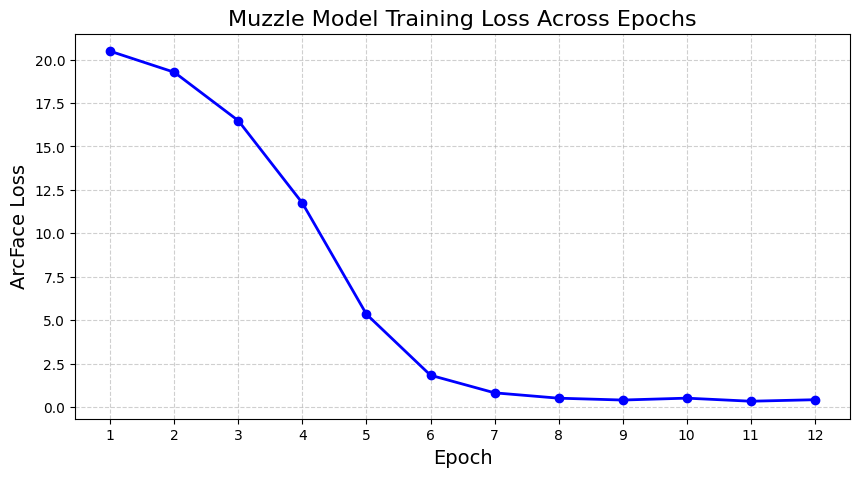

In [ ]:
import matplotlib.pyplot as plt

# Loss values you reported
loss_values = [
    20.4820,
    19.2713,
    16.4832,
    11.7409,
    5.3444,
    1.8335,
    0.8215,
    0.5127,
    0.4066,
    0.5147,
    0.3381,
    0.4247
]

epochs = list(range(1, len(loss_values) + 1))

plt.figure(figsize=(10,5))
plt.plot(epochs, loss_values, marker="o", linewidth=2, color="blue")

plt.title("Muzzle Model Training Loss Across Epochs", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("ArcFace Loss", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.6)

plt.xticks(epochs)
plt.show()


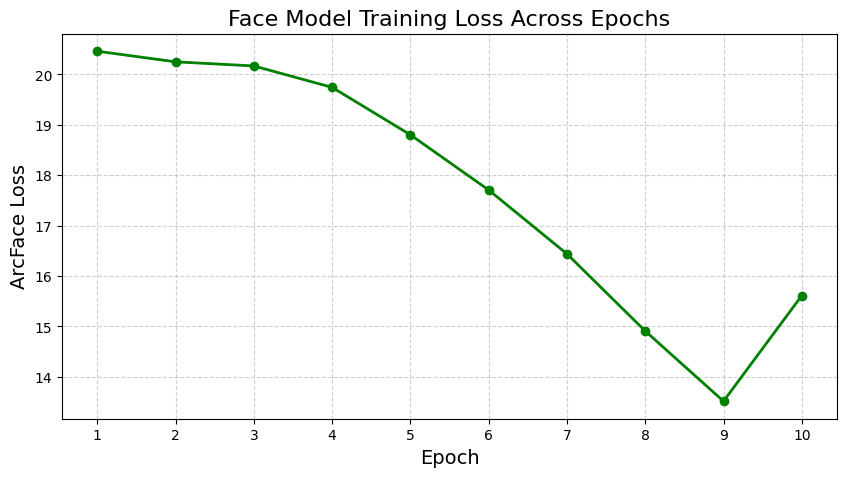

In [ ]:
import matplotlib.pyplot as plt

# Loss values from your FACE model training
face_loss_values = [
    20.4598,
    20.2494,
    20.1675,
    19.7430,
    18.8019,
    17.7063,
    16.4389,
    14.9083,
    13.5157,
    15.6122
]

epochs = list(range(1, len(face_loss_values) + 1))

plt.figure(figsize=(10,5))
plt.plot(epochs, face_loss_values, marker="o", linewidth=2, color="green")

plt.title("Face Model Training Loss Across Epochs", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("ArcFace Loss", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.6)

plt.xticks(epochs)
plt.show()


In [ ]:
def eval_face_open_set(face_model, FACE_TEST, face_gallery, test_tf, device, th_face):
    FP = 0
    total = 0

    for cid in os.listdir(FACE_TEST):
        cdir = os.path.join(FACE_TEST, cid)
        if not os.path.isdir(cdir):
            continue

        for f in os.listdir(cdir):
            if not f.lower().endswith(("jpg","png","jpeg")):
                continue

            total += 1

            try:
                img = test_tf(Image.open(os.path.join(cdir,f)).convert("RGB")).unsqueeze(0).to(device)
                with torch.no_grad():
                    emb = face_model(img).cpu().numpy()[0]
            except:
                continue

            best = -1
            for gemb in face_gallery.values():
                best = max(best, cosine(emb, gemb))

            if best >= th_face:
                FP += 1   # false accept

    FAR = FP / max(1, total)

    print(f"\nFACE @ th={th_face:.3f}")
    print(f"False Accepts (FP): {FP}")
    print(f"Total tests: {total}")
    print(f"FAR: {FAR:.4f}")

    return FP, total, FAR


In [ ]:
for th in [0.9]:
    eval_face_open_set(face_model, FACE_TEST, face_gallery, test_tf, device, th)



FACE @ th=0.900
False Accepts (FP): 8
Total tests: 925
FAR: 0.0086


In [ ]:
def eval_muzzle_open_set(muzzle_model, MUZZLE_TEST, muzzle_gallery, test_tf, device, th_muzzle):
    FP = 0
    total = 0

    for cid in os.listdir(MUZZLE_TEST):
        cdir = os.path.join(MUZZLE_TEST, cid)
        if not os.path.isdir(cdir):
            continue

        for f in os.listdir(cdir):
            if not f.lower().endswith(("jpg","png","jpeg")):
                continue

            total += 1

            try:
                img = test_tf(Image.open(os.path.join(cdir,f)).convert("RGB")).unsqueeze(0).to(device)
                with torch.no_grad():
                    emb = muzzle_model(img).cpu().numpy()[0]
            except:
                continue

            best = -1
            for gemb in muzzle_gallery.values():
                best = max(best, cosine(emb, gemb))

            if best >= th_muzzle:
                FP += 1

    FAR = FP / max(1, total)

    print(f"\nMUZZLE @ th={th_muzzle:.3f}")
    print(f"False Accepts (FP): {FP}")
    print(f"Total tests: {total}")
    print(f"FAR: {FAR:.4f}")

    return FP, total, FAR


In [ ]:
for th in [0.95]:
    eval_muzzle_open_set(muzzle_model, MUZZLE_TEST, muzzle_gallery, test_tf, device, th)



MUZZLE @ th=0.950
False Accepts (FP): 1
Total tests: 925
FAR: 0.0011


In [ ]:
FACE_MODEL_PATH   = "/content/drive/MyDrive/biometrics_new/face_model.pt"
MUZZLE_MODEL_PATH = "/content/drive/MyDrive/biometrics_new/muzzle_model.pt"

os.makedirs("/content/drive/MyDrive/biometrics_new", exist_ok=True)

In [ ]:
torch.save({
    "model_state": face_model.state_dict(),
}, FACE_MODEL_PATH)

torch.save({
    "model_state": muzzle_model.state_dict(),
}, MUZZLE_MODEL_PATH)

print("Saved to Drive:")
print(FACE_MODEL_PATH)
print(MUZZLE_MODEL_PATH)


Saved to Drive:
/content/drive/MyDrive/biometrics_new/face_model.pt
/content/drive/MyDrive/biometrics_new/muzzle_model.pt


In [ ]:
np.save("/content/drive/MyDrive/biometrics/face_gallery.npy", face_gallery)
np.save("/content/drive/MyDrive/biometrics/muzzle_gallery.npy", muzzle_gallery)


In [ ]:
# from google.colab import drive
# drive.mount("/content/drive")

import os
import json
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torchvision.models import resnet50


# ===================== CONFIG =====================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

FACE_MODEL_PATH   = "/content/drive/MyDrive/biometrics_new/face_model.pt"
MUZZLE_MODEL_PATH = "/content/drive/MyDrive/biometrics_new/muzzle_model.pt"

FACE_GALLERY_PATH   = "/content/drive/MyDrive/biometrics/face_gallery.npy"
MUZZLE_GALLERY_PATH = "/content/drive/MyDrive/biometrics/muzzle_gallery.npy"

# NOTE: these are folder-of-folders
TEST_FACE_DIR   = "/content/drive/MyDrive/cattle_data_crops/face_try_test"
TEST_MUZZLE_DIR = "/content/drive/MyDrive/cattle_data_crops/Muzzle_try_test"

OUT_JSON_PATH = "/content/drive/MyDrive/biometrics_new/test_predictions.json"

T_FACE = 0.85
T_MUZZLE = 0.85


# ===================== PREPROCESS =====================
img_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225],
    )
])

def load_img(path):
    img = Image.open(path).convert("RGB")
    return img_tfms(img).unsqueeze(0)


# ===================== MODEL =====================
class FinalCowEmbeddingNet(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        base = resnet50(weights=None)

        self.cnn = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4,
            base.avgpool
        )
        self.fc = nn.Linear(2048, embed_dim)

    def forward(self, x):
        x = self.cnn(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        x = F.normalize(x, dim=1)
        return x


def load_model(pt_path):
    ckpt = torch.load(pt_path, map_location=DEVICE)
    state_dict = ckpt["model_state"]
    model = FinalCowEmbeddingNet(embed_dim=512).to(DEVICE)
    model.load_state_dict(state_dict, strict=False)
    model.eval()
    print("Loaded model:", pt_path)
    return model


# ===================== LOAD GALLERY DICTS =====================
def load_gallery_dict(npy_path):
    obj = np.load(npy_path, allow_pickle=True)
    if isinstance(obj, np.ndarray) and obj.shape == () and obj.dtype == object:
        obj = obj.item()
    if not isinstance(obj, dict):
        raise ValueError(f"Gallery not dict. Got {type(obj)}")
    return obj


face_gallery_dict = load_gallery_dict(FACE_GALLERY_PATH)
muzzle_gallery_dict = load_gallery_dict(MUZZLE_GALLERY_PATH)

common_ids = sorted(set(face_gallery_dict.keys()) & set(muzzle_gallery_dict.keys()))
assert len(common_ids) > 0, "No common IDs between face+muzzle galleries"

face_matrix = np.stack([face_gallery_dict[cid] for cid in common_ids], axis=0).astype(np.float32)
muzzle_matrix = np.stack([muzzle_gallery_dict[cid] for cid in common_ids], axis=0).astype(np.float32)

face_gallery = F.normalize(torch.tensor(face_matrix).to(DEVICE), dim=1)
muzzle_gallery = F.normalize(torch.tensor(muzzle_matrix).to(DEVICE), dim=1)

ids = common_ids


# ===================== LOAD MODELS =====================
face_model   = load_model(FACE_MODEL_PATH)
muzzle_model = load_model(MUZZLE_MODEL_PATH)


# ===================== HELPERS =====================
def list_images(folder):
    exts = (".jpg", ".jpeg", ".png", ".webp")
    return sorted([f for f in os.listdir(folder) if f.lower().endswith(exts)])

@torch.no_grad()
def cosine_sim(a, b):
    a = F.normalize(a, dim=-1)
    b = F.normalize(b, dim=-1)
    return a @ b.T


@torch.no_grad()
def infer_2fa(face_img_path, muzzle_img_path):
    # Face 1:N
    x_face = load_img(face_img_path).to(DEVICE)
    e_face = face_model(x_face)
    sims = cosine_sim(e_face, face_gallery).squeeze(0)

    best_idx = int(torch.argmax(sims).item())
    face_score = float(sims[best_idx].item())
    pred_id = ids[best_idx]

    if face_score < T_FACE:
        return {
            "decision": "REJECT",
            "reason": "Face gate failed",
            "pred_id": None,
            "best_idx": best_idx,
            "face_score": face_score,
            "muzzle_score": None
        }

    # Muzzle 1:1
    x_muzzle = load_img(muzzle_img_path).to(DEVICE)
    e_muzzle = muzzle_model(x_muzzle)

    muzzle_template = muzzle_gallery[best_idx].unsqueeze(0)
    muzzle_score = float(cosine_sim(e_muzzle, muzzle_template).item())

    if muzzle_score < T_MUZZLE:
        return {
            "decision": "REJECT",
            "reason": "Muzzle gate failed",
            "pred_id": pred_id,
            "best_idx": best_idx,
            "face_score": face_score,
            "muzzle_score": muzzle_score
        }

    return {
        "decision": "ACCEPT",
        "reason": "Passed Face + Muzzle gates",
        "pred_id": pred_id,
        "best_idx": best_idx,
        "face_score": face_score,
        "muzzle_score": muzzle_score
    }


# ===================== RUN TEST (SUBFOLDERS) =====================
cow_folders = sorted([d for d in os.listdir(TEST_FACE_DIR) if os.path.isdir(os.path.join(TEST_FACE_DIR, d))])

results = []
skipped = 0

for cow_id in cow_folders:
    face_sub = os.path.join(TEST_FACE_DIR, cow_id)
    muzzle_sub = os.path.join(TEST_MUZZLE_DIR, cow_id)

    if not os.path.exists(muzzle_sub):
        skipped += 1
        continue

    face_imgs = list_images(face_sub)
    muzzle_imgs = list_images(muzzle_sub)

    if len(face_imgs) == 0 or len(muzzle_imgs) == 0:
        skipped += 1
        continue

    # take first image from each folder
    face_path = os.path.join(face_sub, face_imgs[0])
    muzzle_path = os.path.join(muzzle_sub, muzzle_imgs[0])

    out = infer_2fa(face_path, muzzle_path)
    out["true_folder_id"] = cow_id
    out["face_path"] = face_path
    out["muzzle_path"] = muzzle_path
    out["n_face_imgs"] = len(face_imgs)
    out["n_muzzle_imgs"] = len(muzzle_imgs)

    results.append(out)

print("Total cow folders:", len(cow_folders))
print("Predictions done:", len(results))
print("Skipped:", skipped)


# ===================== SAVE =====================
with open(OUT_JSON_PATH, "w") as f:
    json.dump(results, f, indent=2)

print("Saved predictions to:", OUT_JSON_PATH)


Loaded model: /content/drive/MyDrive/biometrics_new/face_model.pt
Loaded model: /content/drive/MyDrive/biometrics_new/muzzle_model.pt
Total cow folders: 93
Predictions done: 93
Skipped: 0
Saved predictions to: /content/drive/MyDrive/biometrics_new/test_predictions.json


In [ ]:
import os
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms


# ==============================
# DEVICE + PREPROCESS
# ==============================
device = "cuda" if torch.cuda.is_available() else "cpu"

test_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std =[0.229,0.224,0.225])
])


# ==============================
# HELPERS
# ==============================
def list_images(folder):
    exts = (".jpg", ".jpeg", ".png", ".webp")
    return sorted([f for f in os.listdir(folder) if f.lower().endswith(exts)])

def load_img(path):
    img = Image.open(path).convert("RGB")
    return test_tf(img).unsqueeze(0)

@torch.no_grad()
def cosine_sim(a, b):
    a = F.normalize(a, dim=-1)
    b = F.normalize(b, dim=-1)
    return a @ b.T


# ==============================
# BUILD IMAGE-LEVEL TEST PAIRS
# ==============================
def build_test_pairs(face_root, muzzle_root, pairing="index"):
    cows = sorted([d for d in os.listdir(face_root) if os.path.isdir(os.path.join(face_root, d))])

    pairs = []
    skipped = 0

    for cow_id in cows:
        face_dir = os.path.join(face_root, cow_id)
        muzzle_dir = os.path.join(muzzle_root, cow_id)

        if not os.path.exists(muzzle_dir):
            skipped += 1
            continue

        face_imgs = list_images(face_dir)
        muzzle_imgs = list_images(muzzle_dir)

        if len(face_imgs) == 0 or len(muzzle_imgs) == 0:
            skipped += 1
            continue

        if pairing == "filename":
            muzzle_set = set(muzzle_imgs)
            common = sorted([f for f in face_imgs if f in muzzle_set])
            for fname in common:
                pairs.append({
                    "true": cow_id,
                    "face_path": os.path.join(face_dir, fname),
                    "muzzle_path": os.path.join(muzzle_dir, fname)
                })

        elif pairing == "index":
            k = min(len(face_imgs), len(muzzle_imgs))
            for i in range(k):
                pairs.append({
                    "true": cow_id,
                    "face_path": os.path.join(face_dir, face_imgs[i]),
                    "muzzle_path": os.path.join(muzzle_dir, muzzle_imgs[i])
                })
        else:
            raise ValueError("pairing must be 'filename' or 'index'")

    print("Total cows:", len(cows))
    print("Total test pairs:", len(pairs))
    print("Skipped cows:", skipped)
    return pairs


# ==============================
# IMAGE-LEVEL EVAL FUNCTION
# ==============================
@torch.no_grad()
def eval_test(face_model, muzzle_model,
              FACE_TEST, MUZZLE_TEST, TRUE_IDS,
              face_gallery, muzzle_gallery, ids,
              th_face, th_muzzle):

    face_model.eval()
    muzzle_model.eval()

    results = []

    for face_path, muzzle_path, true_id in zip(FACE_TEST, MUZZLE_TEST, TRUE_IDS):

        # ---- Face 1:N ----
        x_face = load_img(face_path).to(device)
        e_face = F.normalize(face_model(x_face), dim=1)

        sims = cosine_sim(e_face, face_gallery).squeeze(0)
        best_idx = int(torch.argmax(sims).item())
        face_score = float(sims[best_idx].item())
        pred_id = ids[best_idx]

        if face_score < th_face:
            results.append({
                "true": true_id,
                "pred": None,
                "reason": "Face gate failed",
                "face_score": face_score,
                "muzzle_score": None,
                "best_idx": best_idx
            })
            continue

        # ---- Muzzle 1:1 ----
        x_muzzle = load_img(muzzle_path).to(device)
        e_muzzle = F.normalize(muzzle_model(x_muzzle), dim=1)

        muzzle_temp = muzzle_gallery[best_idx].unsqueeze(0)
        muzzle_score = float(cosine_sim(e_muzzle, muzzle_temp).item())

        if muzzle_score < th_muzzle:
            results.append({
                "true": true_id,
                "pred": None,
                "reason": "Muzzle gate failed",
                "face_score": face_score,
                "muzzle_score": muzzle_score,
                "best_idx": best_idx
            })
            continue

        results.append({
            "true": true_id,
            "pred": pred_id,
            "reason": "Accepted",
            "face_score": face_score,
            "muzzle_score": muzzle_score,
            "best_idx": best_idx
        })

    return results


# ==============================
# OPEN-SET EVALUATION (PRINT ONLY TP FP TAR FAR)
# ==============================
def evaluate_open_set(th_face, th_muzzle,
                      face_model, muzzle_model,
                      FACE_TEST, MUZZLE_TEST, TRUE_IDS,
                      face_gallery, muzzle_gallery, ids):

    results = eval_test(
        face_model, muzzle_model,
        FACE_TEST, MUZZLE_TEST, TRUE_IDS,
        face_gallery, muzzle_gallery, ids,
        th_face, th_muzzle
    )

    # Open-set unknown-only:
    # pred=None => correct reject
    # pred!=None => false accept
    TP = 0
    FP = 0

    for r in results:
        if r["pred"] is not None:
            FP += 1

    total = len(results)
    FAR = FP / max(1, total)

    # TAR not defined here (no known positives), so keep 0
    TAR = 0.0

    print("TP:", TP)
    print("FP:", FP)
    print("TAR:", round(TAR, 4))
    print("FAR:", round(FAR, 4))

    return FAR, TAR, results


# ==============================
# RUN (EDIT THESE PATHS)
# ==============================
TEST_FACE_DIR   = "/content/drive/MyDrive/cattle_data_crops/face_try_test"
TEST_MUZZLE_DIR = "/content/drive/MyDrive/cattle_data_crops/Muzzle_try_test"

# Build test pairs
test_pairs = build_test_pairs(TEST_FACE_DIR, TEST_MUZZLE_DIR, pairing="index")

FACE_TEST   = [x["face_path"] for x in test_pairs]
MUZZLE_TEST = [x["muzzle_path"] for x in test_pairs]
TRUE_IDS    = [x["true"] for x in test_pairs]

# Thresholds
th_face_input = 0.75
th_muzzle_input = 0.80

# Run evaluation
FAR, TAR, results = evaluate_open_set(
    th_face_input, th_muzzle_input,
    face_model, muzzle_model,
    FACE_TEST, MUZZLE_TEST, TRUE_IDS,
    face_gallery, muzzle_gallery, ids
)


Total cows: 93
Total test pairs: 916
Skipped cows: 0
TP: 0
FP: 0
TAR: 0.0
FAR: 0.0


In [ ]:
FACE_MODEL_PATH   = "/content/drive/MyDrive/biometrics_new/face_model.pt"
MUZZLE_MODEL_PATH = "/content/drive/MyDrive/biometrics_new/muzzle_model.pt"

FACE_GALLERY_PATH   = "/content/drive/MyDrive/biometrics/face_gallery.npy"
MUZZLE_GALLERY_PATH = "/content/drive/MyDrive/biometrics/muzzle_gallery.npy"

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
from torchvision.models import resnet50

# =====================
# DEVICE
# =====================
device = "cuda" if torch.cuda.is_available() else "cpu"

# =====================
# PATHS (AS GIVEN)
# =====================
FACE_MODEL_PATH   = "/content/drive/MyDrive/biometrics_new/face_model.pt"
MUZZLE_MODEL_PATH = "/content/drive/MyDrive/biometrics_new/muzzle_model.pt"

FACE_GALLERY_PATH   = "/content/drive/MyDrive/biometrics/face_gallery.npy"
MUZZLE_GALLERY_PATH = "/content/drive/MyDrive/biometrics/muzzle_gallery.npy"

NEW_TEST_ROOT = "/content/drive/MyDrive/cattleDatarefined/all_data_part1"

# =====================
# TRANSFORM
# =====================
tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

def load_img(path):
    img = Image.open(path).convert("RGB")
    return tfm(img).unsqueeze(0)

def list_images(folder):
    exts = (".jpg", ".jpeg", ".png", ".webp")
    return sorted([f for f in os.listdir(folder) if f.lower().endswith(exts)])

@torch.no_grad()
def cosine_sim(a, b):
    a = F.normalize(a, dim=-1)
    b = F.normalize(b, dim=-1)
    return a @ b.T


# =====================
# MODEL
# =====================
class FinalCowEmbeddingNet(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        base = resnet50(weights=None)

        self.cnn = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4,
            base.avgpool
        )
        self.fc = nn.Linear(2048, embed_dim)

    def forward(self, x):
        x = self.cnn(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return F.normalize(x, dim=1)

def load_model(path):
    ckpt = torch.load(path, map_location=device)
    model = FinalCowEmbeddingNet().to(device)
    model.load_state_dict(ckpt["model_state"], strict=False)
    model.eval()
    print("Loaded:", path)
    return model


# =====================
# LOAD MODELS
# =====================
face_model   = load_model(FACE_MODEL_PATH)
muzzle_model = load_model(MUZZLE_MODEL_PATH)


# =====================
# LOAD GALLERIES
# =====================
def load_gallery(path):
    obj = np.load(path, allow_pickle=True)
    if isinstance(obj, np.ndarray) and obj.shape == () and obj.dtype == object:
        obj = obj.item()
    return obj

face_gallery_dict   = load_gallery(FACE_GALLERY_PATH)
muzzle_gallery_dict = load_gallery(MUZZLE_GALLERY_PATH)

ids = sorted(set(face_gallery_dict.keys()) & set(muzzle_gallery_dict.keys()))

face_gallery = torch.tensor(
    np.stack([face_gallery_dict[i] for i in ids]),
    dtype=torch.float32,
    device=device
)
muzzle_gallery = torch.tensor(
    np.stack([muzzle_gallery_dict[i] for i in ids]),
    dtype=torch.float32,
    device=device
)

face_gallery   = F.normalize(face_gallery, dim=1)
muzzle_gallery = F.normalize(muzzle_gallery, dim=1)


# =====================
# BUILD IMAGE PAIRS
# =====================
def build_test_pairs(root):
    cows = sorted(os.listdir(root))
    pairs = []
    skipped = 0

    for cow in cows:
        cow_dir = os.path.join(root, cow)
        if not os.path.isdir(cow_dir):
            continue

        face_dir   = os.path.join(cow_dir, "face")
        muzzle_dir = os.path.join(cow_dir, "muzzle")

        if not os.path.exists(face_dir) or not os.path.exists(muzzle_dir):
            skipped += 1
            continue

        face_imgs   = list_images(face_dir)
        muzzle_imgs = list_images(muzzle_dir)

        if len(face_imgs) == 0 or len(muzzle_imgs) == 0:
            skipped += 1
            continue

        k = min(len(face_imgs), len(muzzle_imgs))
        for i in range(k):
            pairs.append({
                "true": cow,
                "face_path": os.path.join(face_dir, face_imgs[i]),
                "muzzle_path": os.path.join(muzzle_dir, muzzle_imgs[i])
            })

    print("Total image pairs:", len(pairs))
    print("Skipped cows:", skipped)
    return pairs


# =====================
# OPEN-SET IMAGE-WISE EVAL
# =====================
@torch.no_grad()
def eval_open_set_imagewise(
    test_pairs,
    th_face, th_muzzle
):
    FP = 0
    results = []

    for item in test_pairs:
        face_path = item["face_path"]
        muzzle_path = item["muzzle_path"]
        true_id = item["true"]

        # Face gate
        e_face = face_model(load_img(face_path).to(device))
        sims = cosine_sim(e_face, face_gallery).squeeze(0)

        best_idx = int(torch.argmax(sims))
        face_score = float(sims[best_idx])
        pred_id = ids[best_idx]

        if face_score < th_face:
            results.append({
                "true": true_id,
                "pred": None,
                "face_score": face_score,
                "muzzle_score": None,
                "reason": "Face gate failed"
            })
            continue

        # Muzzle gate
        e_muzzle = muzzle_model(load_img(muzzle_path).to(device))
        muzzle_score = float(
            cosine_sim(e_muzzle, muzzle_gallery[best_idx].unsqueeze(0))
        )

        if muzzle_score < th_muzzle:
            results.append({
                "true": true_id,
                "pred": None,
                "face_score": face_score,
                "muzzle_score": muzzle_score,
                "reason": "Muzzle gate failed"
            })
            continue

        results.append({
            "true": true_id,
            "pred": pred_id,
            "face_score": face_score,
            "muzzle_score": muzzle_score,
            "reason": "Accepted"
        })

        FP += 1  # open-set → any accept is false accept

    FAR = FP / max(1, len(results))
    print("Total samples:", len(results))
    print("False accepts:", FP)
    print("FAR:", round(FAR, 4))

    return FAR, results


# =====================
# RUN
# =====================
test_pairs = build_test_pairs(NEW_TEST_ROOT)

th_face   = 0.75
th_muzzle = 0.80

FAR, results = eval_open_set_imagewise(
    test_pairs,
    th_face,
    th_muzzle
)


Loaded: /content/drive/MyDrive/biometrics_new/face_model.pt
Loaded: /content/drive/MyDrive/biometrics_new/muzzle_model.pt
Total image pairs: 2408
Skipped cows: 3
Total samples: 2408
False accepts: 0
FAR: 0.0


In [ ]:
from collections import Counter

@torch.no_grad()
def eval_cowwise_avg(
    root_dir,
    face_model,
    muzzle_model,
    face_gallery,
    muzzle_gallery,
    ids,
    th_face,
    th_muzzle
):
    cows = sorted(os.listdir(root_dir))

    accepted = 0
    rejected = 0
    skipped = 0
    results = []

    for cow_id in cows:
        cow_dir = os.path.join(root_dir, cow_id)
        if not os.path.isdir(cow_dir):
            continue

        face_dir   = os.path.join(cow_dir, "face")
        muzzle_dir = os.path.join(cow_dir, "muzzle")

        if not os.path.exists(face_dir) or not os.path.exists(muzzle_dir):
            skipped += 1
            continue

        face_imgs   = list_images(face_dir)
        muzzle_imgs = list_images(muzzle_dir)

        if len(face_imgs) == 0 or len(muzzle_imgs) == 0:
            skipped += 1
            continue

        # =====================
        # FACE: all images
        # =====================
        face_scores = []
        face_preds = []

        for img in face_imgs:
            x = load_img(os.path.join(face_dir, img)).to(device)
            e = face_model(x)

            sims = cosine_sim(e, face_gallery).squeeze(0)
            idx = int(torch.argmax(sims))
            score = float(sims[idx])

            face_scores.append(score)
            face_preds.append(ids[idx])

        avg_face_score = float(np.mean(face_scores))

        # dominant predicted ID
        pred_id = Counter(face_preds).most_common(1)[0][0]
        best_idx = ids.index(pred_id)

        if avg_face_score < th_face:
            rejected += 1
            results.append({
                "cow": cow_id,
                "decision": "REJECT",
                "reason": "Avg face gate failed",
                "avg_face_score": avg_face_score,
                "avg_muzzle_score": None,
                "pred_id": None
            })
            continue

        # =====================
        # MUZZLE: all images (1:1)
        # =====================
        muzzle_scores = []

        for img in muzzle_imgs:
            x = load_img(os.path.join(muzzle_dir, img)).to(device)
            e = muzzle_model(x)

            score = float(
                cosine_sim(
                    e,
                    muzzle_gallery[best_idx].unsqueeze(0)
                )
            )
            muzzle_scores.append(score)

        avg_muzzle_score = float(np.mean(muzzle_scores))

        if avg_muzzle_score < th_muzzle:
            rejected += 1
            results.append({
                "cow": cow_id,
                "decision": "REJECT",
                "reason": "Avg muzzle gate failed",
                "avg_face_score": avg_face_score,
                "avg_muzzle_score": avg_muzzle_score,
                "pred_id": pred_id
            })
            continue

        # =====================
        # ACCEPT
        # =====================
        accepted += 1
        results.append({
            "cow": cow_id,
            "decision": "ACCEPT",
            "avg_face_score": avg_face_score,
            "avg_muzzle_score": avg_muzzle_score,
            "pred_id": pred_id
        })

    total = accepted + rejected

    print("Total cows evaluated:", total)
    print("Accepted:", accepted)
    print("Rejected:", rejected)
    print("Skipped:", skipped)
    print("Acceptance rate:", round(accepted / max(1, total), 4))

    return results


In [ ]:
th_face   = 0.75
th_muzzle = 0.80

cowwise_results = eval_cowwise_avg(
    NEW_TEST_ROOT,
    face_model,
    muzzle_model,
    face_gallery,
    muzzle_gallery,
    ids,
    th_face,
    th_muzzle
)


Total cows evaluated: 208
Accepted: 0
Rejected: 208
Skipped: 3
Acceptance rate: 0.0
